# 🌦 Weather Monitoring + Machine Learning (Blynk + ML)
This notebook fetches weather data from Blynk Cloud and applies machine learning models (Decision Tree, SVM, KNN) to classify temperature conditions (e.g., High vs Low). It also plots an ROC curve.

In [1]:
# ✅ Step 1: Replace with your Blynk token and virtual pin mapping
BLYNK_TOKEN = "C5JOHzJtX4S5NU7ZpXfCB7bAiIJLDA9b"
V_PINS = {
    'temperature': 'v0',
    'humidity': 'v1',
    'co2': 'v4',
    'pressure': 'v2',
    'altitude': 'v3'
}

In [8]:
import requests
import time
import pandas as pd

def get_blynk_value(pin):
    url = f"https://blynk.cloud/external/api/get?token={BLYNK_TOKEN}&{pin}"
    response = requests.get(url)
    return float(response.text)

# Collect 20 samples every 3 seconds
data = []
for _ in range(200):
    row = {
        'temperature': get_blynk_value(V_PINS['temperature']),
        'humidity': get_blynk_value(V_PINS['humidity']),
        'co2': get_blynk_value(V_PINS['co2']),
        'pressure': get_blynk_value(V_PINS['pressure']),
        'altitude': get_blynk_value(V_PINS['altitude'])
    }
    data.append(row)
    time.sleep(3)

df = pd.DataFrame(data)
df['label'] = (df['temperature'] > df['temperature'].mean()).astype(int)  # 1: High temp, 0: Low temp
df.to_csv("weather_data.csv", index=False)
df.head()

,temperature,humidity,co2,pressure,altitude,label
0,27.0,47.0,1515.0,996.81,137.0,1
1,27.0,46.0,1511.0,996.82,137.0,1
2,27.0,47.0,1505.0,996.77,137.0,1
3,27.0,46.0,1493.0,996.81,137.0,1
4,27.0,46.0,1517.0,996.81,137.0,1


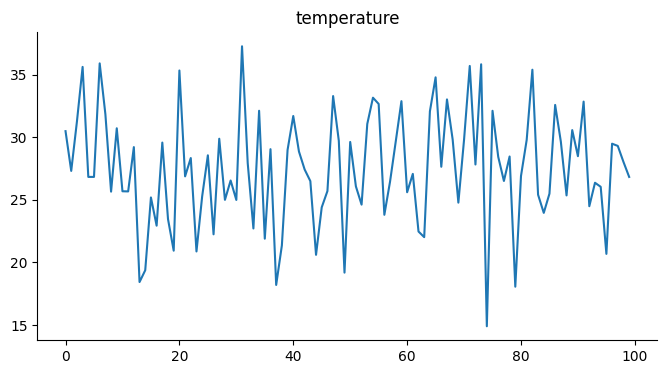

In [17]:
# @title temperature

from matplotlib import pyplot as plt
df['temperature'].plot(kind='line', figsize=(8, 4), title='temperature')
plt.gca().spines[['top', 'right']].set_visible(False)



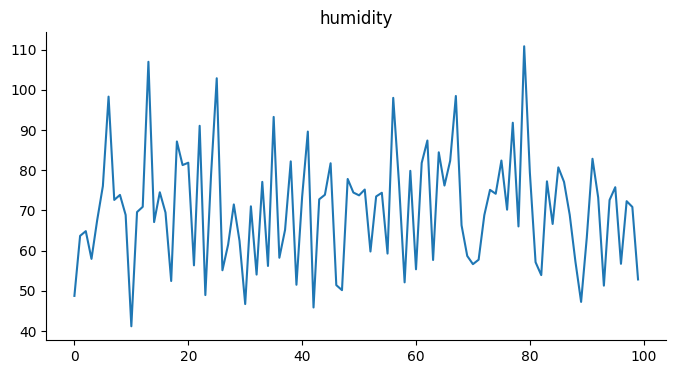

In [15]:
# @title humidity

from matplotlib import pyplot as plt
df['humidity'].plot(kind='line', figsize=(8, 4), title='humidity')
plt.gca().spines[['top', 'right']].set_visible(False)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


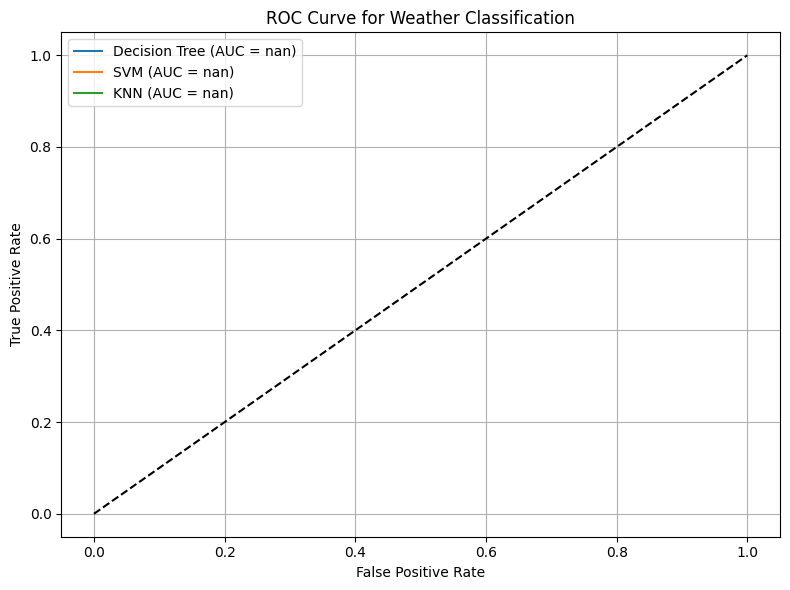

In [3]:
# 🔍 Step 2: Train ML Models

# Import required modules from scikit-learn and matplotlib
from sklearn.model_selection import train_test_split               # For splitting the dataset into training/testing
from sklearn.tree import DecisionTreeClassifier                    # Decision Tree model
from sklearn.svm import SVC                                        # Support Vector Classifier
from sklearn.neighbors import KNeighborsClassifier                 # K-Nearest Neighbors model
from sklearn.metrics import roc_curve, auc                         # For evaluating models using ROC curve and AUC
from sklearn.preprocessing import StandardScaler                   # For feature normalization
import matplotlib.pyplot as plt                                    # For plotting graphs

# Load the dataset previously saved to CSV
df = pd.read_csv("weather_data.csv")                               # Load weather data collected from Blynk into a DataFrame

# Split the data into input features (X) and output labels (y)
X = df[['humidity', 'co2', 'pressure', 'altitude']]                # Features: we exclude temperature (used for labeling)
y = df['label']                                                    # Labels: 1 if temperature > mean, else 0

# Normalize input features (important for models like SVM and KNN)
scaler = StandardScaler()                                          # Create a scaler object
X_scaled = scaler.fit_transform(X)                                 # Fit to data and transform it (mean=0, std=1)

# Split data into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(               # Split the dataset
    X_scaled, y, test_size=0.3, random_state=42                    # 30% test, 70% train. random_state ensures reproducibility
)

# Define a dictionary of models to compare
models = {
    'Decision Tree': DecisionTreeClassifier(),                     # Decision Tree Classifier
    'SVM': SVC(probability=True),                                  # SVM with probability outputs enabled (needed for ROC)
    'KNN': KNeighborsClassifier()                                  # K-Nearest Neighbors Classifier
}

# Create a new figure for ROC curve plots
plt.figure(figsize=(8, 6))                                         # Set the figure size

# Loop over each model, train it, and plot its ROC curve
for name, model in models.items():
    model.fit(X_train, y_train)                                    # Train the model on the training set
    y_prob = model.predict_proba(X_test)[:, 1]                     # Get probability of class 1 (positive class) from predictions
    fpr, tpr, _ = roc_curve(y_test, y_prob)                        # Compute False Positive Rate and True Positive Rate
    roc_auc = auc(fpr, tpr)                                        # Compute Area Under the Curve (AUC) from ROC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")      # Plot the ROC curve for the model

# Plot a diagonal line representing a random guess classifier
plt.plot([0, 1], [0, 1], 'k--')                                    # Dashed line from (0,0) to (1,1)

# Add plot labels and title
plt.xlabel('False Positive Rate')                                  # X-axis label
plt.ylabel('True Positive Rate')                                   # Y-axis label
plt.title('ROC Curve for Weather Classification')                  # Plot title
plt.legend()                                                       # Show the legend with model names and AUC
plt.grid(True)                                                     # Add grid to plot
plt.tight_layout()                                                 # Automatically adjust spacing
plt.show()                                                         # Display the plot


## 🌧️ Rain Prediction (ML-Based)
We simulate a dataset with `rain` labels and train a classifier to predict the possibility of rain based on temperature, humidity, pressure, and altitude.
Finally, we use the trained model to predict rain using **live Blynk data**.

In [4]:
# 📊 Simulated dataset with 'rain' label

import numpy as np                        # Import NumPy for numerical operations
np.random.seed(42)                        # Set a random seed for reproducibility (same random values every time)

n_samples = 100                           # Define number of data points (rows) to simulate

# Generate a DataFrame with random weather-like data
rain_df = pd.DataFrame({
    'temperature': np.random.normal(28, 5, n_samples),   # Temperature values: mean=28°C, std=5
    'humidity': np.random.normal(70, 15, n_samples),     # Humidity values: mean=70%, std=15
    'pressure': np.random.normal(1010, 5, n_samples),    # Atmospheric pressure: mean=1010 hPa, std=5
    'altitude': np.random.normal(10, 2, n_samples),      # Altitude: mean=10 meters, std=2
})

# Create a binary 'rain' label based on simple rule:
# Rain is likely when humidity is high (>80%) and pressure is low (<1008 hPa)
rain_df['rain'] = ((rain_df['humidity'] > 80) & (rain_df['pressure'] < 1008)).astype(int)

# Save the simulated data to a CSV file
rain_df.to_csv("rain_data.csv", index=False)             # Save without row indices

# Preview the first 5 rows of the dataset
rain_df.head()                                           # Show sample data


,temperature,humidity,pressure,altitude,rain
0,30.483571,48.769439,1011.788937,8.342010,0
1,27.308678,63.690320,1012.803923,8.879638,0
2,31.238443,64.859282,1015.415256,11.494587,0
3,35.615149,57.965841,1015.269010,11.220741,0
4,26.829233,67.580714,1003.111653,9.958197,0


In [12]:
# 🌦 Train model for rain prediction

from sklearn.ensemble import RandomForestClassifier     # Import the Random Forest Classifier

# Load the simulated rain dataset
df = pd.read_csv("rain_data.csv")                       # Read previously saved synthetic weather data

# Split the dataset into features (X) and label (y)
X = df[['temperature', 'humidity', 'pressure', 'altitude']]  # Input features
y = df['rain']                                               # Output label: 1 = rain, 0 = no rain

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Initialize and train a Random Forest classifier on the training data
rain_model = RandomForestClassifier()                   # Create a Random Forest model instance
rain_model.fit(X_train, y_train)                        # Train the model with training data

# Evaluate and print the accuracy of the model on the test set
print("🌦 Rain Prediction Model Accuracy:", rain_model.score(X_test, y_test))  # Print the model's accuracy


🌦 Rain Prediction Model Accuracy: 0.9666666666666667


In [13]:
# 🌐 Live prediction using current Blynk sensor values

# Create a list containing one row of live weather data fetched from Blynk
live_weather = [[
    get_blynk_value(V_PINS['temperature']),   # Get live temperature value from Blynk
    get_blynk_value(V_PINS['humidity']),      # Get live humidity value
    get_blynk_value(V_PINS['pressure']),      # Get live pressure value
    get_blynk_value(V_PINS['altitude'])       # Get live altitude value
]]

# Predict the probability of rain using the trained Random Forest model
rain_prob = rain_model.predict_proba(live_weather)[0][1]  # Index [0][1] gives probability of class '1' (Rain)

# Print the result based on threshold of 0.5 (50%)
print("🌧️ Rain Likely!" if rain_prob > 0.5 else "☀️ No Rain Expected.")  # Show message based on prediction

# Print the exact probability of rain
print(f"Probability of Rain: {rain_prob*100:.2f}%")                     # Show rain probability as a percentage


☀️ No Rain Expected.
Probability of Rain: 17.00%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
